# connect kaggle

In [ ]:
!pip install -q kaggle

# declare token
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_a08f9b6b9025401467ead523f76d243c"

# down data
!kaggle datasets download -d faldoae/padangfood

!unzip -q padangfood.zip -d padang_dataset
print("finish")

Dataset URL: https://www.kaggle.com/datasets/faldoae/padangfood
License(s): ODbL-1.0
padangfood.zip: Skipping, found more recently modified local copy (use --force to force download)
replace padang_dataset/dataset_padang_food/ayam_goreng/ayam_goreng (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: finish


#Load & Inspect Data

In [ ]:
import pandas as pd
from pathlib import Path

# declare data path
data_dir = 'padang_dataset/dataset_padang_food'

# initilize list
paths = []
labels = []

print("scanning folder...")
for path in Path(data_dir).rglob('*.*'):
    if path.is_file():
        paths.append(str(path))         # save img path
        labels.append(path.parent.name)

# Create dataframe
df = pd.DataFrame({'path': paths, 'species': labels})

# sort table
df = df.sort_values('species').reset_index(drop=True)

# check
print("=========================================")
print(f"succesfull")
print(f"total img: {len(df)}")
print(f"Classes: {df['species'].nunique()}")
print("=========================================")
print("\ncheck first 5 row:")
display(df.head())

scanning folder...
succesfull
total img: 993
Classes: 9

check first 5 row:


,path,species
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng


# Feature Extraction

In [ ]:
import cv2
import numpy as np
import os
from tqdm.notebook import tqdm

# Initialize lists to store parameters
widths, heights, aspect_ratios, file_sizes = [], [], [], []
mean_r, mean_g, mean_b = [], [], []
brightness, contrast, sharpness = [], [], []

print("starting scan img...")

# loop img in dataframe
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    img_path = row['path']

    # check file size
    file_sizes.append(os.path.getsize(img_path) / 1024.0)

    img = cv2.imread(img_path)

    if img is not None:
        # Size
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h if h != 0 else 0)

        # Color
        # OpenCV read img using the BGR color system, then -> RGB.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_r.append(img_rgb[:, :, 0].mean())
        mean_g.append(img_rgb[:, :, 1].mean())
        mean_b.append(img_rgb[:, :, 2].mean())

        # Quality Metrics
        # Convert img to black, white -> brightness, contrast, and sharpness
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(gray.mean())               # Mean
        contrast.append(gray.std())                  # Standard deviation
        sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var()) # sharp
    else:
        # if error -> none
        widths.append(None); heights.append(None); aspect_ratios.append(None)
        mean_r.append(None); mean_g.append(None); mean_b.append(None)
        brightness.append(None); contrast.append(None); sharpness.append(None)

# push paramto to dataframe
df['width'] = widths
df['height'] = heights
df['aspect_ratio'] = aspect_ratios
df['file_size_kb'] = file_sizes
df['mean_r'] = mean_r
df['mean_g'] = mean_g
df['mean_b'] = mean_b
df['brightness'] = brightness
df['contrast'] = contrast
df['sharpness'] = sharpness

# delete img error
df = df.dropna().reset_index(drop=True)

print("\nFinish")
print("Display:")
display(df.head())

starting scan img...


  0%|          | 0/993 [00:00<?, ?it/s]


Finish
Display:


,path,species,width,height,aspect_ratio,file_size_kb,mean_r,mean_g,mean_b,brightness,contrast,sharpness
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,445,474,0.938819,130.026367,141.823870,92.287275,77.887783,105.467937,64.987572,564.929653
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,505,404,1.250000,75.637695,160.780531,102.188305,81.104867,117.315587,70.135562,1085.133958
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,640,480,1.333333,191.596680,136.150495,101.063024,82.237656,109.421266,59.770518,2995.577492
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,293,221,1.325792,42.094727,133.523157,103.160394,88.514308,110.580946,60.027773,4310.990873
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,1150,677,1.698671,169.363281,128.405361,105.610503,84.401792,110.007255,51.064408,522.761668


#Visualizations

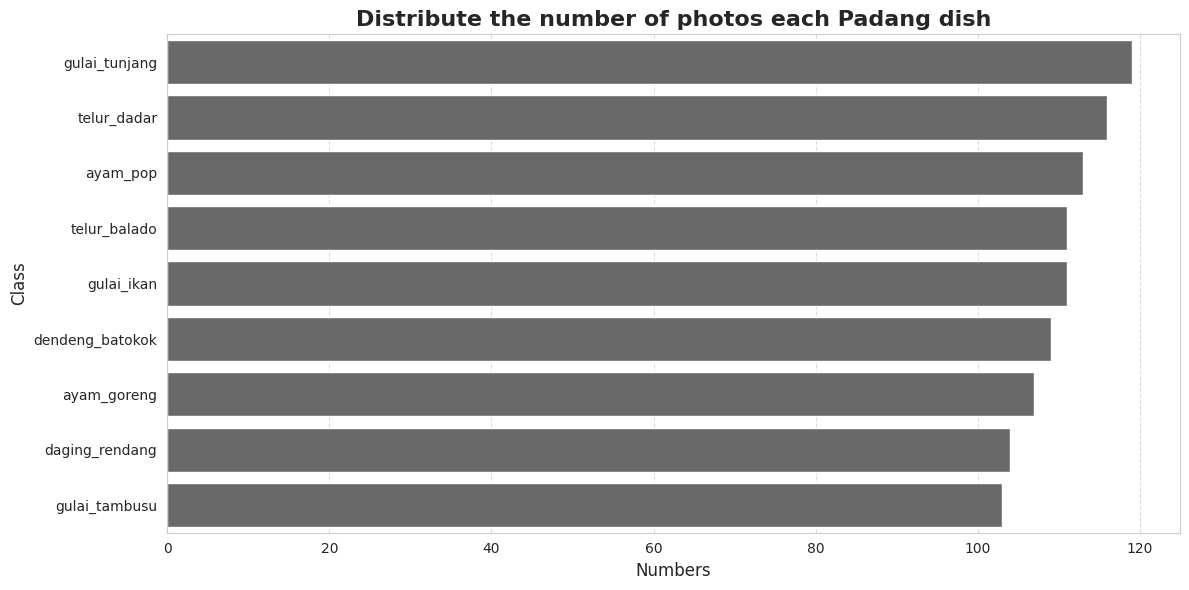

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='species', order=df['species'].value_counts().index, color='dimgray')

plt.title('Distribute the number of photos each Padang dish', fontsize=16, fontweight='bold')
plt.xlabel('Numbers', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cv2

# list class
classes = sorted(df['species'].unique().tolist())

# scrool menu
dropdown = widgets.Dropdown(
    options=classes,
    value=classes[0],
    description='choose:',
    style={'description_width': 'initial'}
)
output = widgets.Output()

# change img when choose another class
def update_gallery(change):
    with output:
        clear_output(wait=True)
        selected_class = change.new

        # select random img in class
        class_df = df[df['species'] == selected_class]
        sample_imgs = class_df.sample(min(4, len(class_df))).reset_index(drop=True)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"img: {selected_class.upper().replace('_', ' ')}", fontsize=16, fontweight='bold', y=1.05)

        for i in range(4):
            if i < len(sample_imgs):
                # Read, display img
                img = cv2.imread(sample_imgs.loc[i, 'path'])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f"Size: {img.shape[1]}x{img.shape[0]}")
            else:
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()

dropdown.observe(update_gallery, names='value')
display(dropdown, output)
dropdown.value = classes[1]
dropdown.value = classes[0]

Dropdown(description='choose:', options=('ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gula…

Output()

/tmp/ipykernel_1276/1311763811.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rgb_data, x='Color channel', y='Pixel value', palette=['#ef4444', '#22c55e', '#3b82f6'], ax=axes[1, 0])


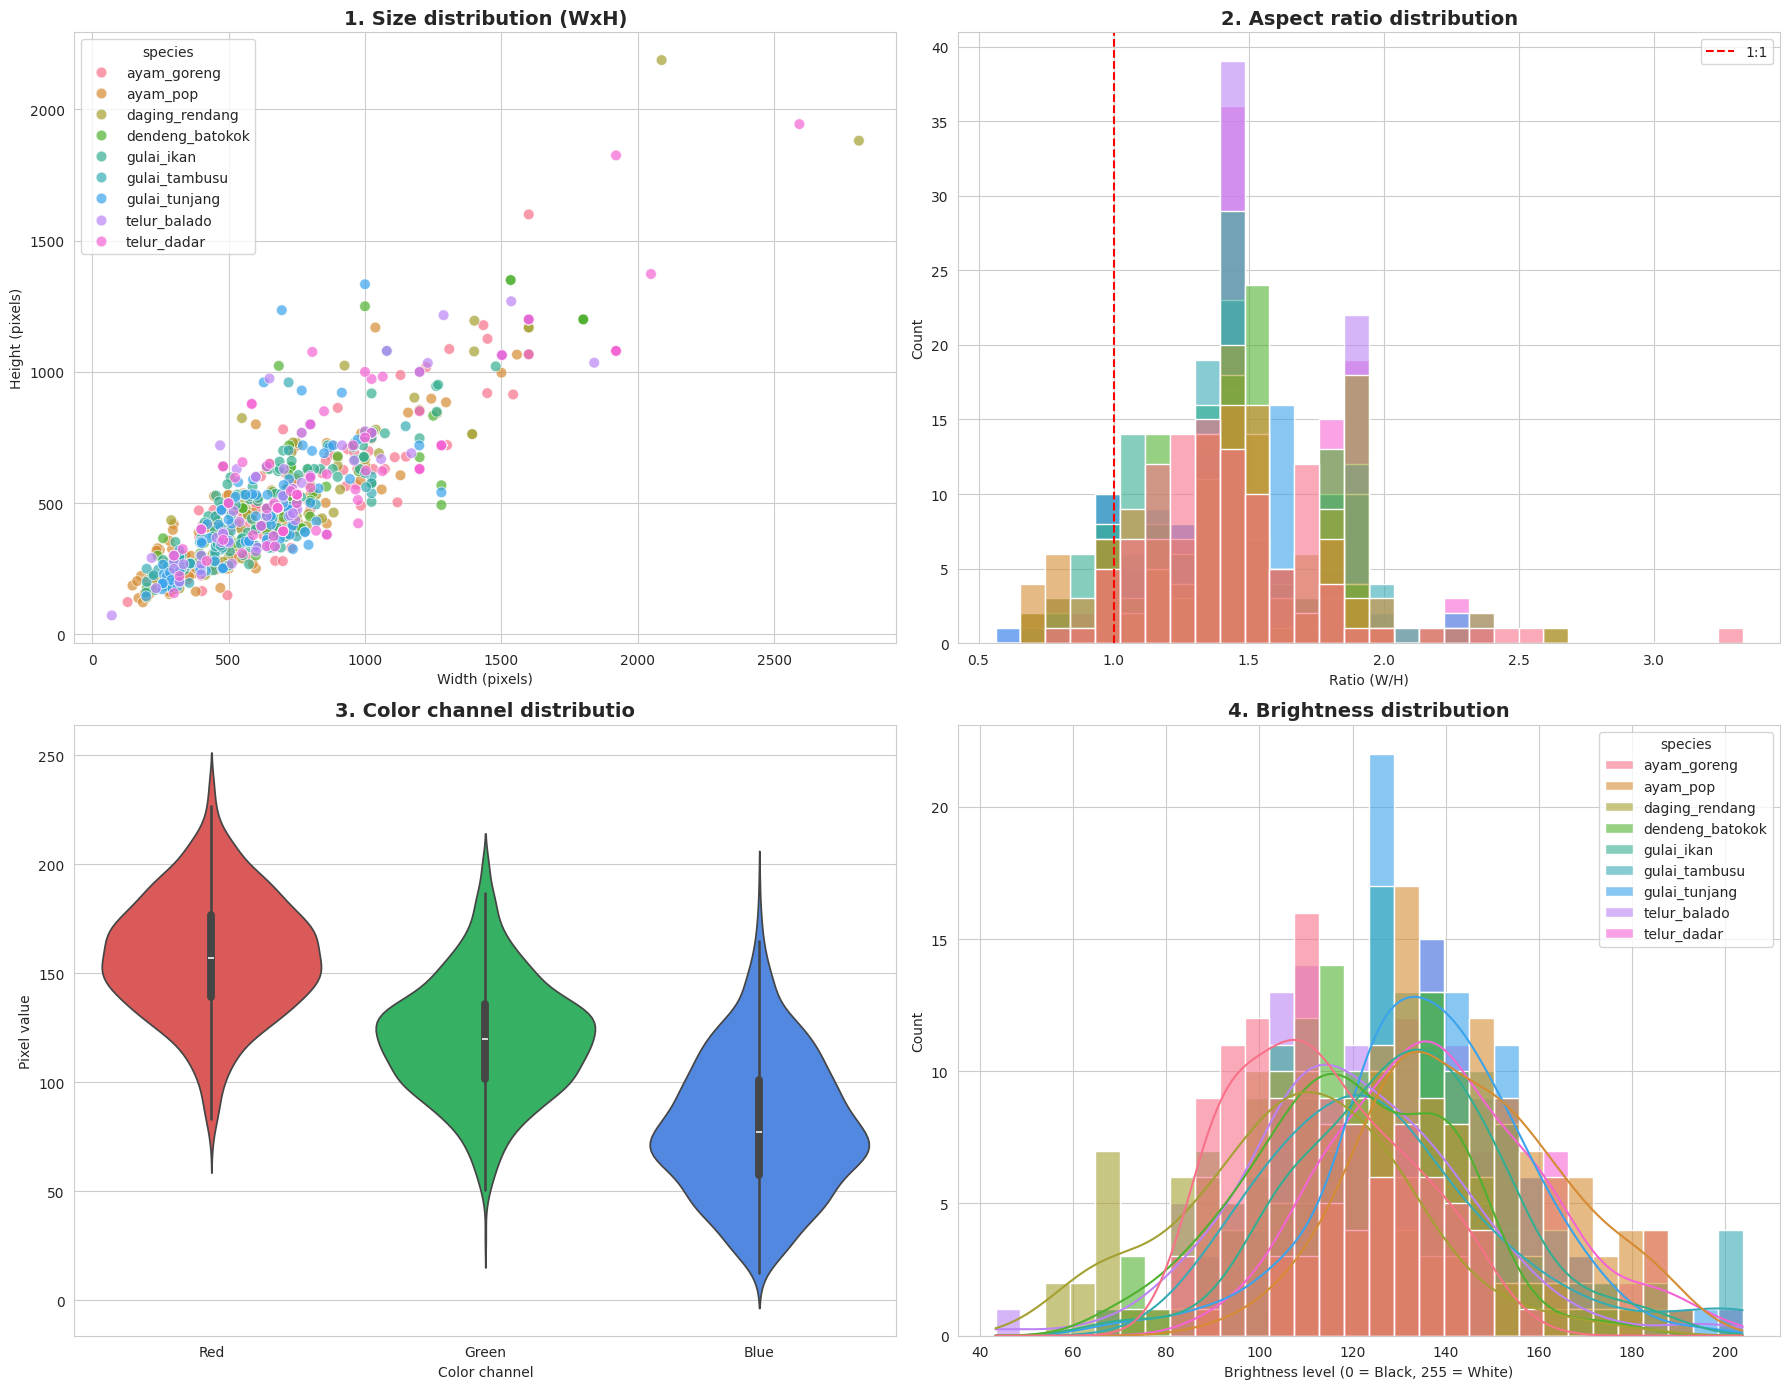

STATISTICS:
- Avg width: 730 px (Min: 72, Max: 2810)
- Avg height: 518 px (Min: 72, Max: 2188)
- Avg size: 119.2 KB


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# create color fo 9 classes
sns.set_style("whitegrid")
species_list = df['species'].unique()
palette = sns.color_palette("husl", len(species_list))
colors_dict = dict(zip(species_list, palette))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Chart 1: Size distribution (WxH)
sns.scatterplot(data=df, x='width', y='height', hue='species', palette=colors_dict,
                s=60, alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('1. Size distribution (WxH)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)'); axes[0, 0].set_ylabel('Height (pixels)')

# Chart 2: Aspect ratio distribution
sns.histplot(data=df, x='aspect_ratio', hue='species', palette=colors_dict,
             bins=30, alpha=0.6, ax=axes[0, 1])
axes[0, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='1:1')
axes[0, 1].set_title('2. Aspect ratio distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ratio (W/H)'); axes[0, 1].legend()

# Chart 3: Color channel distribution (RGB)
rgb_data = pd.DataFrame({
    'Pixel value': pd.concat([df['mean_r'], df['mean_g'], df['mean_b']]),
    'Color channel': ['Red']*len(df) + ['Green']*len(df) + ['Blue']*len(df)
})
sns.violinplot(data=rgb_data, x='Color channel', y='Pixel value', palette=['#ef4444', '#22c55e', '#3b82f6'], ax=axes[1, 0])
axes[1, 0].set_title('3. Color channel distributio', fontsize=14, fontweight='bold')

# Chart 4: Brightness distribution
sns.histplot(data=df, x='brightness', hue='species', palette=colors_dict,
             bins=30, alpha=0.6, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('4. Brightness distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Brightness level (0 = Black, 255 = White)')

plt.tight_layout()
plt.show()

# In thống kê chung
print("STATISTICS:")
print(f"- Avg width: {df['width'].mean():.0f} px (Min: {df['width'].min()}, Max: {df['width'].max()})")
print(f"- Avg height: {df['height'].mean():.0f} px (Min: {df['height'].min()}, Max: {df['height'].max()})")
print(f"- Avg size: {df['file_size_kb'].mean():.1f} KB")